In [2]:
%pip install oauth2client

import pandas as pd
import numpy as np
import gspread
from oauth2client.service_account import ServiceAccountCredentials
import matplotlib.pyplot as plt

# ใช้ username และ password แทน service account json
from gspread.exceptions import APIError

import os

# Define the scope for Google Sheets and Drive API
scope = ['https://spreadsheets.google.com/feeds', 'https://www.googleapis.com/auth/drive']

credentials_path = r"..\Service Account\gen-lang-client-0406795509-bc06ec2e33dc.json"
# Use ServiceAccountCredentials and gspread.authorize only if credentials file exists
if os.path.exists(credentials_path):
	credentials = ServiceAccountCredentials.from_json_keyfile_name(credentials_path, scope)
	gc = gspread.authorize(credentials)

	# ── Master (Store Master) from Google Sheets ──────────────────────
	sheet_master = gc.open_by_url("https://docs.google.com/spreadsheets/d/1PiFiOJyxoI6aDR9xdU4HIl8KoDG-50PwYuL4Bm9f8Fk/edit?gid=0#gid=0")
	ws_master = sheet_master.worksheet("Store master")
	Master = pd.DataFrame(ws_master.get_all_records())

	# ── Ref_Survey_Database ─────────────────────────────────────────────
	sheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/1jNP96tfKsehXOS1EknpoO5fkcDbonyu4mEWxxxa3zKE/edit?usp=sharing")
	worksheet = sheet.worksheet("Ref_Survey_Database")
	data = worksheet.get_all_records()
	df_refig_survey = pd.DataFrame(data)
	
	# ── Aircon_Survey_Database ─────────────────────────────────────────────
	sheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/1jNP96tfKsehXOS1EknpoO5fkcDbonyu4mEWxxxa3zKE/edit?usp=sharing")
	worksheet = sheet.worksheet("Aircon_Survey_Database")
	data = worksheet.get_all_records()
	df_aircon_survey = pd.DataFrame(data)


else:
	print(f"Warning: {credentials_path} not found. Skipping Google Sheets import.")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:

# ใช้ข้อมูลล่าสุดของแต่ละ Branch Code (ทั้ง Refig และ Aircon)
df_refig_survey_Clean = (
    df_refig_survey
    .dropna(subset=['Branch Code'])
    .assign(Timestamp=pd.to_datetime(df_refig_survey['Timestamp'], errors='coerce'))
    .sort_values(['Branch Code', 'Timestamp'], na_position='first')
    .drop_duplicates(subset=['Branch Code'], keep='last')
    .reset_index(drop=True)
)

df_aircon_survey_clean = (
    df_aircon_survey
    .dropna(subset=['Branch Code'])
    .assign(Timestamp=pd.to_datetime(df_aircon_survey['Timestamp'], errors='coerce'))
    .sort_values(['Branch Code', 'Timestamp'], na_position='first')
    .drop_duplicates(subset=['Branch Code'], keep='last')
    .reset_index(drop=True)
)

In [4]:
merged_critical_df = pd.merge(df_refig_survey_Clean, df_aircon_survey_clean, on='Branch Code', how='outer', 
                        suffixes=('_Refig', '_Aircon')).merge(Master[['Gold text', 'AMM MTN (23)', 'Date Open Store','Status']], 
                        left_on='Branch Code', right_on='Gold text', how='right').drop(columns=['Gold text'] )

In [5]:
cols = df_refig_survey_Clean.columns.tolist()
qty_cols = [c for c in cols if c.endswith('Qty')]
print("=== จำนวนตู้แต่ละประเภท (Clean data) ===")
for c in qty_cols:
    total = pd.to_numeric(df_refig_survey_Clean[c], errors='coerce').sum()
    stores = (pd.to_numeric(df_refig_survey_Clean[c], errors='coerce') > 0).sum()
    print(f"{c:30s}  รวม {int(total):5d} ตัว  ({stores} สาขา)")

=== จำนวนตู้แต่ละประเภท (Clean data) ===
Ref Open Qty                    รวม  6451 ตัว  (1180 สาขา)
Ref Bev Walk In Qty             รวม   332 ตัว  (193 สาขา)
Ref Frozen3 Door Qty            รวม    91 ตัว  (142 สาขา)
Ref Ice Cream Qty               รวม  2095 ตัว  (1098 สาขา)
Ref Ice Qty                     รวม  1794 ตัว  (1112 สาขา)
Ref Frozen1 Door Qty            รวม  2855 ตัว  (999 สาขา)
Ref Bev Plugin Qty              รวม  1882 ตัว  (741 สาขา)
Ref Frozen2 Door Qty            รวม   129 ตัว  (132 สาขา)
Ref Bev Remote Qty              รวม   620 ตัว  (266 สาขา)
Ref Ss4 Door Qty                รวม  1314 ตัว  (708 สาขา)


In [6]:
cols = df_refig_survey_Clean.columns.tolist()
type_prefixes = {
    'Open':       'Ref Open',
    'Bev Walk In':'Ref Bev Walk In',
    'Frozen 3D':  'Ref Frozen3 Door',
    'Ice Cream':  'Ref Ice Cream',
    'Ice':        'Ref Ice',
    'Frozen 1D':  'Ref Frozen1 Door',
    'Bev Plugin': 'Ref Bev Plugin',
    'Frozen 2D':  'Ref Frozen2 Door',
    'Bev Remote': 'Ref Bev Remote',
    'SS 4D':      'Ref Ss4 Door',
}

print("=== ยี่ห้อแต่ละประเภท ===")
for label, prefix in type_prefixes.items():
    brand_cols = [c for c in cols if c.startswith(prefix) and 'Brand' in c]
    brands = pd.Series(dtype=str)
    for bc in brand_cols:
        brands = pd.concat([brands, df_refig_survey_Clean[bc].astype(str)], ignore_index=True)
    brands = brands[brands.notna() & (brands != '') & (brands != 'nan') & (brands != '0')]
    top = brands.value_counts().head(8)
    if len(top) > 0:
        print(f"[{label}]: " + ", ".join(f"{b}({n})" for b,n in top.items()))

=== ยี่ห้อแต่ละประเภท ===
[Open]: Themedez(2068), VSR(1865), Panasonic(1265), Carrier(355), Systemform(234), Sanyo(68), SANYO(48), SANYO SMI(42)
[Bev Walk In]: Themedez(99), Panasonic(92), VSR(54), Systemform(10), Sanyo(8), Carrier(7), SANYO(6), Other(4)
[Ice Cream]: LIEBHERR(361), Liebherr(251), Hiron(228), Other(98), The Cool(83), Haier(65), LIEBHERR (38), Panasonic(29)
[Ice]: Panasonic(860), LIEBHERR(412), Themedez(337), Liebherr(269), Hiron(228), The Cool(211), Other(127), VSR(112)
[Bev Plugin]: Themedez(682), VSR(500), Panasonic(257), Carrier(114), Pattana Inter Cool(97), Systemform(76), Sanden(52), Sanyo(15)
[Bev Remote]: Themedez(233), VSR(169), Panasonic(59), Systemform(23), Carrier(17), Pattana Inter Cool(13), COOLPOINT(7), Dixell(5)
[SS 4D]: Themedez(318), VSR(216), Panasonic(206), Sanden(118), Carrier(72), Systemform(65), Other(23), Sanyo(22)


In [7]:
cols = df_refig_survey_Clean.columns.tolist()
type_prefixes = {
    'Open':       'Ref Open',
    'Bev Walk In':'Ref Bev Walk In',
    'Frozen 3D':  'Ref Frozen3 Door',
    'Ice Cream':  'Ref Ice Cream',
    'Ice':        'Ref Ice',
    'Frozen 1D':  'Ref Frozen1 Door',
    'Bev Plugin': 'Ref Bev Plugin',
    'Frozen 2D':  'Ref Frozen2 Door',
    'Bev Remote': 'Ref Bev Remote',
    'SS 4D':      'Ref Ss4 Door',
}

print("=== สินค้าที่ใส่ในตู้ ===")
for label, prefix in type_prefixes.items():
    prod_cols = [c for c in cols if c.startswith(prefix) and 'Product' in c]
    products = pd.Series(dtype=str)
    for pc in prod_cols:
        products = pd.concat([products, df_refig_survey_Clean[pc].astype(str)], ignore_index=True)
    products = products[products.notna() & (products != '') & (products != 'nan') & (products != '0')]
    top = products.value_counts().head(8)
    if len(top) > 0:
        print(f"[{label}]: " + ", ".join(f"{p}({n})" for p,n in top.items()))
    else:
        print(f"[{label}]: ไม่มีข้อมูล Product")

=== สินค้าที่ใส่ในตู้ ===
[Open]: อื่นๆ(1581), อาหารพร้อมทาน(1100), ยำ/โยเกิร์ต/น้ำผลไม้(985), หมู/ไก่/เนื้อสัตว์(975), แซนวิช/แฮมเบอร์เกอร์/แพนเวิ่ง(591), แซนวิช/แฮมเบอร์เกอร์/แพนเวิ่ง, อาหารพร้อมทาน(289), ยำ/โยเกิร์ต/น้ำผลไม้, อื่นๆ(257), อาหารพร้อมทาน, อื่นๆ(131)
[Bev Walk In]: เครื่องดื่ม(297), อื่นๆ(4), เครื่องดื่ม, อื่นๆ(3), เครื่องดื่ม, อาหารสด(2), อาหารสด(2)
[Frozen 3D]: ไม่มีข้อมูล Product
[Ice Cream]: ไอศครีม(4)
[Ice]: ไอศครีม(4), น้ำแข็ง(3)
[Frozen 1D]: ไม่มีข้อมูล Product
[Bev Plugin]: เครื่องดื่ม(1706), อื่นๆ(81), อาหารสด(40), เครื่องดื่ม, อื่นๆ(18), เครื่องดื่ม, อาหารสด(5), อาหารสด, อื่นๆ(1)
[Frozen 2D]: ไม่มีข้อมูล Product
[Bev Remote]: เครื่องดื่ม(482), อื่นๆ(19), เครื่องดื่ม, อื่นๆ(5), เครื่องดืม(5), อาหารสด(3), เครื่องดื่ม, อาหารสด(3), น้ำอัดลม(2)
[SS 4D]: ไม่มีข้อมูล Product


In [8]:
cols = df_refig_survey_Clean.columns.tolist()
# ตรวจ brand columns สำหรับ Frozen types
for prefix in ['Ref Frozen', 'Ref Ss4', 'Ref Ice Cream']:
    brand_cols = [c for c in cols if c.startswith(prefix) and 'Brand' in c]
    print(f"{prefix}: brand_cols = {brand_cols[:5]}")
    # ตรวจ Asset No, Model, Type columns ด้วย
    other_cols = [c for c in cols if c.startswith(prefix)][:10]
    print(f"  first cols: {other_cols}")

Ref Frozen: brand_cols = ['Ref Frozen Brand_1', 'Ref Frozen Brand_3', 'Ref Frozen Brand_2', 'Ref Frozen Brand_4', 'Ref Frozen Brand_6']
  first cols: ['Ref Frozen3 Door Qty', 'Ref Frozen1 Door Qty', 'Ref Frozen Brand_1', 'Ref Frozen Asset No_1', 'Ref Frozen Asset No_3', 'Ref Frozen Brand_3', 'Ref Frozen Brand_2', 'Ref Frozen Brand_4', 'Ref Frozen Asset No_2', 'Ref Frozen Asset No_4']
Ref Ss4: brand_cols = ['Ref Ss4 Door Brand_2', 'Ref Ss4 Door Brand_1', 'Ref Ss4 Door Brand_3', 'Ref Ss4 Door Brand_4', 'Ref Ss4 Door Brand_5']
  first cols: ['Ref Ss4 Door Brand_2', 'Ref Ss4 Door Asset No_1', 'Ref Ss4 Door Asset No_2', 'Ref Ss4 Door Brand_1', 'Ref Ss4 Door Qty', 'Ref Ss4 Door Status_1', 'Ref Ss4 Door Status_2', 'Ref Ss4 Door Brand_3', 'Ref Ss4 Door Asset No_3', 'Ref Ss4 Door Status_3']
Ref Ice Cream: brand_cols = ['Ref Ice Cream Brand_1', 'Ref Ice Cream Brand_3', 'Ref Ice Cream Brand_2', 'Ref Ice Cream Brand_4']
  first cols: ['Ref Ice Cream Qty', 'Ref Ice Cream Asset No_1', 'Ref Ice Cream

In [ ]:
cols = df_refig_survey_Clean.columns.tolist()
# ยี่ห้อ Frozen (รวม 1D, 2D, 3D) และ Ice Cream
for label, prefix in [('Frozen (ทุกขนาด)', 'Ref Frozen'), ('Ice Cream', 'Ref Ice Cream'), ('Ice', 'Ref Ice B')]:
    brand_cols = [c for c in cols if c.startswith(prefix) and 'Brand' in c]
    brands = pd.Series(dtype=str)
    for bc in brand_cols:
        brands = pd.concat([brands, df_refig_survey_Clean[bc].astype(str)], ignore_index=True)
    brands = brands[brands.notna() & (brands != '') & (brands != 'nan') & (brands != '0')]
    top = brands.value_counts().head(10)
    print(f"[{label}]: " + ", ".join(f"{b}({n})" for b,n in top.items()))

[Frozen (ทุกขนาด)]: Themedez(849), Sanden(590), Panasonic(512), VSR(314), Carrier(139), iarp(133), Systemform(110), Iarp(67), IARP(65), Sanyo(46)
[Ice Cream]: LIEBHERR(361), Liebherr(251), Hiron(228), Other(98), The Cool(83), Haier(65), LIEBHERR (38), Panasonic(29), Themedez(27), Sanden(20)
[Ice]: Panasonic(831), Themedez(310), The Cool(128), VSR(105), Sanden(88), MIRAGE(55), LIEBHERR(51), Mirage(36), Carrier(30), Other(29)


In [11]:
# ── ตรวจสอบโครงสร้างข้อมูล ──
print("=== Master columns (ที่มีคำว่า date/open/year) ===")
for c in Master.columns:
    if any(k in c.lower() for k in ['date', 'open', 'year', 'วัน', 'เปิด']):
        print(f"  {c}")

print("\n=== Master columns ทั้งหมด ===")
print(Master.columns.tolist())

print("\n=== df_refig_survey_Clean - Ref Open columns (20 แรก) ===")
open_cols = [c for c in df_refig_survey_Clean.columns if 'Open' in c]
print(open_cols[:20])

=== Master columns (ที่มีคำว่า date/open/year) ===
  Date Open Store
  Already open Month

=== Master columns ทั้งหมด ===
['Gold text', 'GOLD Code', 'Store Name(th) (2)', 'Store Name(en) (3)', 'BU Type (20)', 'ID DD (13)', 'DD Name (14)', 'ID CM (10)', 'CM Name (11)', 'ID AMM (22)', 'AMM MTN (23)', 'AMM MTN DUMMY', 'Tel AMM', 'HUB CODE (17)', 'HUB (18)', 'Date Open Store', 'Status', 'FlowType_Format', 'BU', 'BCM DM Region', 'BCM CM Region', 'FC Flag(Y/N)', 'Oracle Code', 'Address (4)', 'ถนน', 'ตำบล', 'District', 'Province', 'Postal Code', 'Latitude', 'Longitude', 'store name - code', 'ภูมิภาค', 'VP Opts', 'Contract', 'Already open Month', 'MMS Team', 'e-mail SGM', 'e-mail DM BCM', 'e-mail CM BCM']

=== df_refig_survey_Clean - Ref Open columns (20 แรก) ===
['Ref Open Qty', 'Ref Open Asset No_4', 'Ref Open Asset No_2', 'Ref Open Brand_6', 'Ref Open Product_4', 'Ref Open Asset No_3', 'Ref Open Product_2', 'Ref Open Brand_2', 'Ref Open Product_3', 'Ref Open Asset No_6', 'Ref Open Brand_1',

In [10]:
# import os
# from openpyxl import Workbook
# from openpyxl.styles import PatternFill, Font, Alignment, Border, Side, numbers
# from openpyxl.utils import get_column_letter
# from openpyxl.worksheet.table import Table, TableStyleInfo
# from datetime import datetime

# OUTPUT_PATH = os.path.join(os.path.dirname(os.path.abspath("Refig_Survey_Analysys.ipynb")), "Refig_Survey_Report.xlsx")

# cols = df_refig_survey_Clean.columns.tolist()

# type_prefixes = {
#     'Ref Open':       'Ref Open',
#     'Bev Walk In':    'Ref Bev Walk In',
#     'Frozen 3D':      'Ref Frozen3 Door',
#     'Ice Cream':      'Ref Ice Cream',
#     'Ice':            'Ref Ice',
#     'Frozen 1D':      'Ref Frozen1 Door',
#     'Bev Plugin':     'Ref Bev Plugin',
#     'Frozen 2D':      'Ref Frozen2 Door',
#     'Bev Remote':     'Ref Bev Remote',
#     'SS 4D':          'Ref Ss4 Door',
# }

# qty_cols = [c for c in cols if c.endswith('Qty')]

# wb = Workbook()

# # ─────────────────────────────────────────────────────────────
# # SHEET 1 : Summary Report
# # ─────────────────────────────────────────────────────────────
# ws_sum = wb.active
# ws_sum.title = "Summary"

# HEADER_FILL  = PatternFill("solid", fgColor="1F4E79")
# HEADER_FONT  = Font(bold=True, color="FFFFFF", size=11)
# SUBHDR_FILL  = PatternFill("solid", fgColor="2E75B6")
# SUBHDR_FONT  = Font(bold=True, color="FFFFFF", size=10)
# ALT_FILL     = PatternFill("solid", fgColor="D6E4F0")
# TOTAL_FILL   = PatternFill("solid", fgColor="BDD7EE")
# TOTAL_FONT   = Font(bold=True, size=10)
# BORDER       = Border(
#     left   = Side(style='thin'),
#     right  = Side(style='thin'),
#     top    = Side(style='thin'),
#     bottom = Side(style='thin'),
# )

# def set_cell(ws, row, col, value, fill=None, font=None, align_center=False, number_format=None):
#     cell = ws.cell(row=row, column=col, value=value)
#     cell.border = BORDER
#     if fill:   cell.fill = fill
#     if font:   cell.font = font
#     if align_center: cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
#     if number_format: cell.number_format = number_format
#     return cell

# # ── Title ──
# ws_sum.merge_cells("A1:F1")
# t = ws_sum["A1"]
# t.value = f"สรุปข้อมูลตู้แช่ (Refrigeration Survey)  —  Export: {datetime.today().strftime('%d/%m/%Y')}"
# t.font = Font(bold=True, size=14, color="FFFFFF")
# t.fill = HEADER_FILL
# t.alignment = Alignment(horizontal='center', vertical='center')
# ws_sum.row_dimensions[1].height = 30

# # ── Section A : จำนวนตู้แต่ละประเภท ──
# ws_sum.merge_cells("A2:F2")
# c2 = ws_sum["A2"]
# c2.value = "A.  จำนวนตู้แช่แต่ละประเภท"
# c2.font = SUBHDR_FONT
# c2.fill = SUBHDR_FILL
# c2.alignment = Alignment(horizontal='left', vertical='center')
# ws_sum.row_dimensions[2].height = 20

# headers_A = ["ประเภทตู้แช่", "รหัสคอลัมน์", "จำนวน (ตัว)", "จำนวนสาขา", "เฉลี่ย/สาขา"]
# for ci, h in enumerate(headers_A, 1):
#     set_cell(ws_sum, 3, ci, h, fill=PatternFill("solid", fgColor="2E75B6"),
#              font=Font(bold=True, color="FFFFFF", size=10), align_center=True)

# label_map = {
#     'Ref Open Qty':          'ตู้แช่เปิด (Open)',
#     'Ref Bev Walk In Qty':   'ห้องเย็นเครื่องดื่ม (Walk-in)',
#     'Ref Frozen3 Door Qty':  'ตู้แช่แข็ง 3 ประตู (Frozen 3D)',
#     'Ref Ice Cream Qty':     'ตู้ไอศกรีม (Ice Cream)',
#     'Ref Ice Qty':           'ตู้น้ำแข็ง (Ice)',
#     'Ref Frozen1 Door Qty':  'ตู้แช่แข็ง 1 ประตู (Frozen 1D)',
#     'Ref Bev Plugin Qty':    'ตู้แช่เครื่องดื่ม Plugin (Bev Plugin)',
#     'Ref Frozen2 Door Qty':  'ตู้แช่แข็ง 2 ประตู (Frozen 2D)',
#     'Ref Bev Remote Qty':    'ตู้แช่เครื่องดื่ม Remote (Bev Remote)',
#     'Ref Ss4 Door Qty':      'ตู้ SS 4 ประตู (SS 4D)',
# }

# row = 4
# grand_total_units = 0
# for i, qc in enumerate(qty_cols):
#     nums = pd.to_numeric(df_refig_survey_Clean[qc], errors='coerce')
#     total_u = int(nums.sum())
#     store_c = int((nums > 0).sum())
#     avg = round(total_u / store_c, 2) if store_c > 0 else 0
#     grand_total_units += total_u
#     fill = ALT_FILL if i % 2 == 0 else None
#     set_cell(ws_sum, row, 1, label_map.get(qc, qc), fill=fill)
#     set_cell(ws_sum, row, 2, qc, fill=fill)
#     set_cell(ws_sum, row, 3, total_u, fill=fill, align_center=True, number_format='#,##0')
#     set_cell(ws_sum, row, 4, store_c, fill=fill, align_center=True, number_format='#,##0')
#     set_cell(ws_sum, row, 5, avg, fill=fill, align_center=True, number_format='#,##0.00')
#     row += 1

# # Grand total row
# set_cell(ws_sum, row, 1, "รวมทั้งหมด", fill=TOTAL_FILL, font=TOTAL_FONT)
# set_cell(ws_sum, row, 2, "", fill=TOTAL_FILL)
# set_cell(ws_sum, row, 3, grand_total_units, fill=TOTAL_FILL, font=TOTAL_FONT, align_center=True, number_format='#,##0')
# set_cell(ws_sum, row, 4, "", fill=TOTAL_FILL)
# set_cell(ws_sum, row, 5, "", fill=TOTAL_FILL)
# row += 2

# # ── Section B : ยี่ห้อ (Brand) ──
# ws_sum.merge_cells(f"A{row}:F{row}")
# ws_sum.cell(row=row, column=1).value = "B.  ยี่ห้อตู้แช่แต่ละประเภท (Top 8)"
# ws_sum.cell(row=row, column=1).font = SUBHDR_FONT
# ws_sum.cell(row=row, column=1).fill = SUBHDR_FILL
# ws_sum.cell(row=row, column=1).alignment = Alignment(horizontal='left', vertical='center')
# ws_sum.row_dimensions[row].height = 20
# row += 1

# headers_B = ["ประเภทตู้แช่", "อันดับ", "ยี่ห้อ", "จำนวน (ครั้ง)"]
# for ci, h in enumerate(headers_B, 1):
#     set_cell(ws_sum, row, ci, h, fill=PatternFill("solid", fgColor="2E75B6"),
#              font=Font(bold=True, color="FFFFFF", size=10), align_center=True)
# row += 1

# brand_prefixes = {
#     'ตู้แช่เปิด':              ('Ref Open',       'Ref Open'),
#     'ห้องเย็นเครื่องดื่ม':     ('Bev Walk In',    'Ref Bev Walk In'),
#     'ตู้แช่แข็ง (1D/2D/3D)':  ('Frozen',         'Ref Frozen'),
#     'ตู้ไอศกรีม':              ('Ice Cream',      'Ref Ice Cream'),
#     'ตู้น้ำแข็ง':              ('Ice',            'Ref Ice B'),
#     'ตู้แช่เครื่องดื่ม Plugin': ('Bev Plugin',    'Ref Bev Plugin'),
#     'ตู้แช่เครื่องดื่ม Remote': ('Bev Remote',    'Ref Bev Remote'),
#     'ตู้ SS 4 ประตู':           ('SS 4D',         'Ref Ss4 Door'),
# }

# alt = 0
# for type_label, (_, prefix) in brand_prefixes.items():
#     brand_cols_t = [c for c in cols if c.startswith(prefix) and 'Brand' in c]
#     brands_s = pd.Series(dtype=str)
#     for bc_col in brand_cols_t:
#         brands_s = pd.concat([brands_s, df_refig_survey_Clean[bc_col].astype(str)], ignore_index=True)
#     brands_s = brands_s[brands_s.notna() & (brands_s != '') & (brands_s != 'nan') & (brands_s != '0')]
#     top_brands = brands_s.value_counts().head(8)
#     if len(top_brands) == 0:
#         continue
#     first = True
#     for rank, (brand_name, cnt_b) in enumerate(top_brands.items(), 1):
#         fill = ALT_FILL if alt % 2 == 0 else None
#         set_cell(ws_sum, row, 1, type_label if first else "", fill=fill)
#         set_cell(ws_sum, row, 2, rank, fill=fill, align_center=True)
#         set_cell(ws_sum, row, 3, brand_name, fill=fill)
#         set_cell(ws_sum, row, 4, int(cnt_b), fill=fill, align_center=True, number_format='#,##0')
#         first = False
#         row += 1
#     alt += 1

# # ── Section C : สินค้า (Product) ──
# row += 1
# ws_sum.merge_cells(f"A{row}:F{row}")
# ws_sum.cell(row=row, column=1).value = "C.  สินค้าในตู้แต่ละประเภท (Top 8)"
# ws_sum.cell(row=row, column=1).font = SUBHDR_FONT
# ws_sum.cell(row=row, column=1).fill = SUBHDR_FILL
# ws_sum.cell(row=row, column=1).alignment = Alignment(horizontal='left', vertical='center')
# ws_sum.row_dimensions[row].height = 20
# row += 1

# headers_C = ["ประเภทตู้แช่", "อันดับ", "สินค้า", "จำนวน (ครั้ง)"]
# for ci, h in enumerate(headers_C, 1):
#     set_cell(ws_sum, row, ci, h, fill=PatternFill("solid", fgColor="2E75B6"),
#              font=Font(bold=True, color="FFFFFF", size=10), align_center=True)
# row += 1

# product_prefixes = {
#     'ตู้แช่เปิด':               'Ref Open',
#     'ห้องเย็นเครื่องดื่ม':      'Ref Bev Walk In',
#     'ตู้ไอศกรีม':               'Ref Ice Cream',
#     'ตู้น้ำแข็ง':               'Ref Ice',
#     'ตู้แช่เครื่องดื่ม Plugin':  'Ref Bev Plugin',
#     'ตู้แช่เครื่องดื่ม Remote':  'Ref Bev Remote',
# }

# alt2 = 0
# for type_label, prefix in product_prefixes.items():
#     prod_cols_t = [c for c in cols if c.startswith(prefix) and 'Product' in c]
#     products_s = pd.Series(dtype=str)
#     for pc_col in prod_cols_t:
#         products_s = pd.concat([products_s, df_refig_survey_Clean[pc_col].astype(str)], ignore_index=True)
#     products_s = products_s[products_s.notna() & (products_s != '') & (products_s != 'nan') & (products_s != '0')]
#     top_prods = products_s.value_counts().head(8)
#     if len(top_prods) == 0:
#         continue
#     first = True
#     for rank, (prod_name, cnt_p) in enumerate(top_prods.items(), 1):
#         fill = ALT_FILL if alt2 % 2 == 0 else None
#         set_cell(ws_sum, row, 1, type_label if first else "", fill=fill)
#         set_cell(ws_sum, row, 2, rank, fill=fill, align_center=True)
#         set_cell(ws_sum, row, 3, prod_name, fill=fill)
#         set_cell(ws_sum, row, 4, int(cnt_p), fill=fill, align_center=True, number_format='#,##0')
#         first = False
#         row += 1
#     alt2 += 1

# # column widths
# for col_idx, w in zip(range(1, 7), [40, 30, 18, 14, 14, 14]):
#     ws_sum.column_dimensions[get_column_letter(col_idx)].width = w

# # ─────────────────────────────────────────────────────────────
# # SHEET 2 : Raw Data (Refig Survey Clean)
# # ─────────────────────────────────────────────────────────────
# ws_raw = wb.create_sheet("Raw Data - Refig")
# raw_df = df_refig_survey_Clean.copy()

# # Write header
# for ci, col_name in enumerate(raw_df.columns, 1):
#     cell = ws_raw.cell(row=1, column=ci, value=col_name)
#     cell.fill = HEADER_FILL
#     cell.font = HEADER_FONT
#     cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
#     cell.border = BORDER

# # Write data
# for ri, data_row in enumerate(raw_df.itertuples(index=False), 2):
#     fill = ALT_FILL if ri % 2 == 0 else None
#     for ci, val in enumerate(data_row, 1):
#         cell = ws_raw.cell(row=ri, column=ci, value=val if val != '' else None)
#         cell.border = BORDER
#         if fill: cell.fill = fill
#         cell.alignment = Alignment(vertical='center')

# # Excel Table on Raw sheet
# table_ref = f"A1:{get_column_letter(len(raw_df.columns))}{len(raw_df)+1}"
# tbl = Table(displayName="RefigSurveyRaw", ref=table_ref)
# tbl.tableStyleInfo = TableStyleInfo(name="TableStyleMedium2", showFirstColumn=False,
#                                     showLastColumn=False, showRowStripes=True, showColumnStripes=False)
# ws_raw.add_table(tbl)

# # auto-width first 15 cols only (others may be too many)
# for ci in range(1, min(16, len(raw_df.columns)+1)):
#     col_vals = [str(raw_df.iloc[r, ci-1]) for r in range(min(200, len(raw_df)))]
#     max_len = max([len(str(raw_df.columns[ci-1]))] + [len(v) for v in col_vals if v not in ('', 'nan', 'None')])
#     ws_raw.column_dimensions[get_column_letter(ci)].width = min(max_len + 2, 40)

# ws_raw.freeze_panes = "A2"

# # ─────────────────────────────────────────────────────────────
# # SHEET 3 : Raw Data (Merged)
# # ─────────────────────────────────────────────────────────────
# ws_merged = wb.create_sheet("Raw Data - Merged")
# mg_df = merged_critical_df.copy()

# for ci, col_name in enumerate(mg_df.columns, 1):
#     cell = ws_merged.cell(row=1, column=ci, value=col_name)
#     cell.fill = HEADER_FILL
#     cell.font = HEADER_FONT
#     cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
#     cell.border = BORDER

# for ri, data_row in enumerate(mg_df.itertuples(index=False), 2):
#     fill = ALT_FILL if ri % 2 == 0 else None
#     for ci, val in enumerate(data_row, 1):
#         cell = ws_merged.cell(row=ri, column=ci, value=val if val != '' else None)
#         cell.border = BORDER
#         if fill: cell.fill = fill
#         cell.alignment = Alignment(vertical='center')

# table_ref2 = f"A1:{get_column_letter(len(mg_df.columns))}{len(mg_df)+1}"
# tbl2 = Table(displayName="MergedSurveyRaw", ref=table_ref2)
# tbl2.tableStyleInfo = TableStyleInfo(name="TableStyleMedium6", showFirstColumn=False,
#                                      showLastColumn=False, showRowStripes=True, showColumnStripes=False)
# ws_merged.add_table(tbl2)
# ws_merged.freeze_panes = "A2"

# for ci in range(1, min(16, len(mg_df.columns)+1)):
#     col_vals = [str(mg_df.iloc[r, ci-1]) for r in range(min(200, len(mg_df)))]
#     max_len = max([len(str(mg_df.columns[ci-1]))] + [len(v) for v in col_vals if v not in ('', 'nan', 'None')])
#     ws_merged.column_dimensions[get_column_letter(ci)].width = min(max_len + 2, 40)

# # ─────────────────────────────────────────────────────────────
# # Save
# # ─────────────────────────────────────────────────────────────
# wb.save(OUTPUT_PATH)
# print(f"✅ Saved: {OUTPUT_PATH}")
# print(f"   Sheet 'Summary'          : {row-1} rows")
# print(f"   Sheet 'Raw Data - Refig' : {len(raw_df)} rows × {len(raw_df.columns)} cols")
# print(f"   Sheet 'Raw Data - Merged': {len(mg_df)} rows × {len(mg_df.columns)} cols")

PermissionError: [Errno 13] Permission denied: 'g:\\My Drive\\00. Web Projects\\Air_Ref_Servey\\Pyhon ANL\\Refig_Survey_Report.xlsx'

In [13]:
print("Master GOLD Code sample:", Master['GOLD Code'].head(5).tolist())
print("Branch Code sample:", df_refig_survey_Clean['Branch Code'].head(5).tolist())
print("Date Open Store sample:", Master['Date Open Store'].head(5).tolist())
print("Already open Month sample:", Master['Already open Month'].head(5).tolist())
print("Status unique:", Master['Status'].unique()[:10])
print("Open Product cols:", [c for c in df_refig_survey_Clean.columns if 'Open' in c and 'Product' in c])
print("Ref Open Qty:", df_refig_survey_Clean['Ref Open Qty'].describe())

Master GOLD Code sample: [11101, 11102, 11103, 11104, 11106]
Branch Code sample: [11235, 21002, 21005, 21007, 21009]
Date Open Store sample: ['1/9/1995', '15/1/1994', '25/11/1994', '17/6/1995', '1/2/1996']
Already open Month sample: [366, 386, 376, 369, 361]
Status unique: ['A' 'I' 0]
Open Product cols: ['Ref Open Product_4', 'Ref Open Product_2', 'Ref Open Product_3', 'Ref Open Product_1', 'Ref Open Product_5', 'Ref Open Product_6', 'Ref Open Product_7', 'Ref Open Product_8', 'Ref Open Product_9', 'Ref Open Product_12', 'Ref Open Product_11', 'Ref Open Product_10', 'Ref Open Product_13', 'Ref Open Product_24', 'Ref Open Product_55', 'Ref Open Product_42', 'Ref Open Product_32', 'Ref Open Product_38', 'Ref Open Product_63', 'Ref Open Product_57', 'Ref Open Product_50', 'Ref Open Product_59', 'Ref Open Product_31', 'Ref Open Product_39', 'Ref Open Product_15', 'Ref Open Product_35', 'Ref Open Product_52', 'Ref Open Product_18', 'Ref Open Product_54', 'Ref Open Product_66', 'Ref Open Pro

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

rcParams['font.family'] = 'Tahoma'
rcParams['axes.unicode_minus'] = False

TODAY = pd.Timestamp.today().normalize()

# ═══════════════════════════════════════════════════════════
# 1.  Prepare Master — active stores only
# ═══════════════════════════════════════════════════════════
master_active = Master[Master['Status'] == 'A'].copy()
master_active['Date Open Store'] = pd.to_datetime(
    master_active['Date Open Store'], dayfirst=True, errors='coerce')
master_active['Already open Month'] = pd.to_numeric(
    master_active['Already open Month'], errors='coerce')
master_active['Store Age (yrs)'] = (
    (TODAY - master_active['Date Open Store']).dt.days / 365.25).round(1)
master_active['Open Year'] = master_active['Date Open Store'].dt.year

# ═══════════════════════════════════════════════════════════
# 2.  Identify stores with Ref Open + อาหารพร้อมทาน
# ═══════════════════════════════════════════════════════════
ref_df = df_refig_survey_Clean.copy()
ref_df['Ref Open Qty Num'] = pd.to_numeric(ref_df['Ref Open Qty'], errors='coerce').fillna(0)
open_prod_cols = [c for c in ref_df.columns if c.startswith('Ref Open Product')]

keywords = ['อาหาร', 'พร้อมทาน', 'แซนวิช', 'หมู', 'ยำ', 'โยเกิร์ต', 'น้ำผลไม้']
prod_text = ref_df[open_prod_cols].astype(str)
prod_mask = prod_text.apply(lambda col: col.str.contains('|'.join(keywords), na=False)).any(axis=1)
qty_mask = ref_df['Ref Open Qty Num'] >= 1

rte_stores = ref_df[qty_mask & prod_mask][
    ['Branch Code', 'Branch Name', 'DM Area', 'CM Area', 'Ref Open Qty Num']].copy()
rte_stores['Branch Code'] = rte_stores['Branch Code'].astype(str).str.strip()
print(f"สาขาที่มีตู้ Ref Open + อาหารพร้อมทาน: {len(rte_stores)} สาขา")

# ═══════════════════════════════════════════════════════════
# 3.  Merge กับ Master เพื่อได้ Date Open Store
# ═══════════════════════════════════════════════════════════
master_active['GOLD Code'] = master_active['GOLD Code'].astype(str).str.strip()
analysis_df = rte_stores.merge(
    master_active[['GOLD Code', 'Store Name(th) (2)', 'Date Open Store',
                   'Store Age (yrs)', 'Open Year', 'Already open Month',
                   'BCM DM Region', 'BCM CM Region', 'HUB (18)', 'Province']],
    left_on='Branch Code', right_on='GOLD Code', how='left'
)
analysis_df.drop(columns=['GOLD Code'], inplace=True)

# fallback: ใช้ Already open Month ถ้า Date ไม่มี
no_date = analysis_df['Store Age (yrs)'].isna()
analysis_df.loc[no_date, 'Store Age (yrs)'] = (
    pd.to_numeric(analysis_df.loc[no_date, 'Already open Month'], errors='coerce') / 12).round(1)

analysis_df['Store Age (yrs)'] = pd.to_numeric(analysis_df['Store Age (yrs)'], errors='coerce')
analysis_df['Open Year'] = pd.to_numeric(analysis_df['Open Year'], errors='coerce')

print(f"หลัง merge: {len(analysis_df)} สาขา  |  Date พบ: {analysis_df['Date Open Store'].notna().sum()}")
print(f"Store Age range: {analysis_df['Store Age (yrs)'].min():.1f} – {analysis_df['Store Age (yrs)'].max():.1f} ปี")
analysis_df.head(3)

สาขาที่มีตู้ Ref Open + อาหารพร้อมทาน: 1156 สาขา
หลัง merge: 1156 สาขา  |  Date พบ: 1156
Store Age range: 0.0 – 19.9 ปี


,Branch Code,Branch Name,DM Area,CM Area,Ref Open Qty Num,Store Name(th) (2),Date Open Store,Store Age (yrs),Open Year,Already open Month,BCM DM Region,BCM CM Region,HUB (18),Province
0,21002,MBC อุดมสุข,น.ส.รัชดาพร อีศรัตน์,น.ส.กรรณิการ์ พุทธวงค์,6.0,MBC อุดมสุข,2006-05-14,19.9,2006,238.0,#N/A,#N/A,MBC อุดมสุข,กรุงเทพมหานคร
1,21005,MBC ชินเขต,น.ส.รัชดาพร อีศรัตน์,น.ส.นิตยา สมจิตร,7.0,MBC ชินเขต,2008-07-29,17.7,2008,211.0,#N/A,#N/A,MBC BCP สุวินทวงศ์,กรุงเทพมหานคร
2,21007,MBC บางพลี,นายอนุกูล ศรีลัดดา,น.ส.วีรนันท์ แสงใส,4.0,MBC บางพลี,2010-07-31,15.7,2010,187.0,#N/A,#N/A,BCM ชุมชนเกาะเรียน พระนครศรีอยุธยา,สมุทรปราการ


In [17]:
def classify_risk(age):
    if pd.isna(age):   return 'Unknown'
    if age < 5:        return '1_Low'
    elif age < 8:      return '2_Medium'
    elif age < 11:     return '3_High'
    else:              return '4_Critical'

RISK_LABEL = {
    '1_Low':      '🟢 Low  (< 5 ปี)',
    '2_Medium':   '🟡 Medium (5–7 ปี)',
    '3_High':     '🔴 High (8–10 ปี)',
    '4_Critical': '⛔ Critical (> 10 ปี)',
    'Unknown':    'ไม่ทราบ'
}
RISK_COLORS_HEX = {
    '1_Low':      '#2ecc71',
    '2_Medium':   '#f1c40f',
    '3_High':     '#e67e22',
    '4_Critical': '#c0392b',
    'Unknown':    '#95a5a6'
}
RISK_ORDER_KEYS = ['1_Low', '2_Medium', '3_High', '4_Critical', 'Unknown']

analysis_df['Risk Key']   = analysis_df['Store Age (yrs)'].apply(classify_risk)
analysis_df['Risk Level'] = analysis_df['Risk Key'].map(RISK_LABEL)
analysis_df['Risk Color'] = analysis_df['Risk Key'].map(RISK_COLORS_HEX)

risk_summary = (analysis_df.groupby('Risk Key', sort=True)
    .agg(Stores=('Branch Code','count'),
         Units=('Ref Open Qty Num','sum'),
         AvgAge=('Store Age (yrs)','mean'))
    .reindex([k for k in RISK_ORDER_KEYS if k in analysis_df['Risk Key'].unique()])
    .reset_index())
risk_summary['AvgAge'] = risk_summary['AvgAge'].round(1)
risk_summary['Units']  = risk_summary['Units'].astype(int)
risk_summary['Label']  = risk_summary['Risk Key'].map(RISK_LABEL)

print("=== Risk Summary ===")
for _, r in risk_summary.iterrows():
    print(f"  {r['Label']:30s}  {r['Stores']:4d} สาขา  |  {r['Units']:5d} ตัว  |  อายุเฉลี่ย {r['AvgAge']:.1f} ปี")

=== Risk Summary ===
  🟢 Low  (< 5 ปี)                  354 สาขา  |   2102 ตัว  |  อายุเฉลี่ย 2.9 ปี
  🟡 Medium (5–7 ปี)                494 สาขา  |   2864 ตัว  |  อายุเฉลี่ย 6.5 ปี
  🔴 High (8–10 ปี)                 152 สาขา  |    817 ตัว  |  อายุเฉลี่ย 8.9 ปี
  ⛔ Critical (> 10 ปี)             156 สาขา  |    528 ตัว  |  อายุเฉลี่ย 13.2 ปี


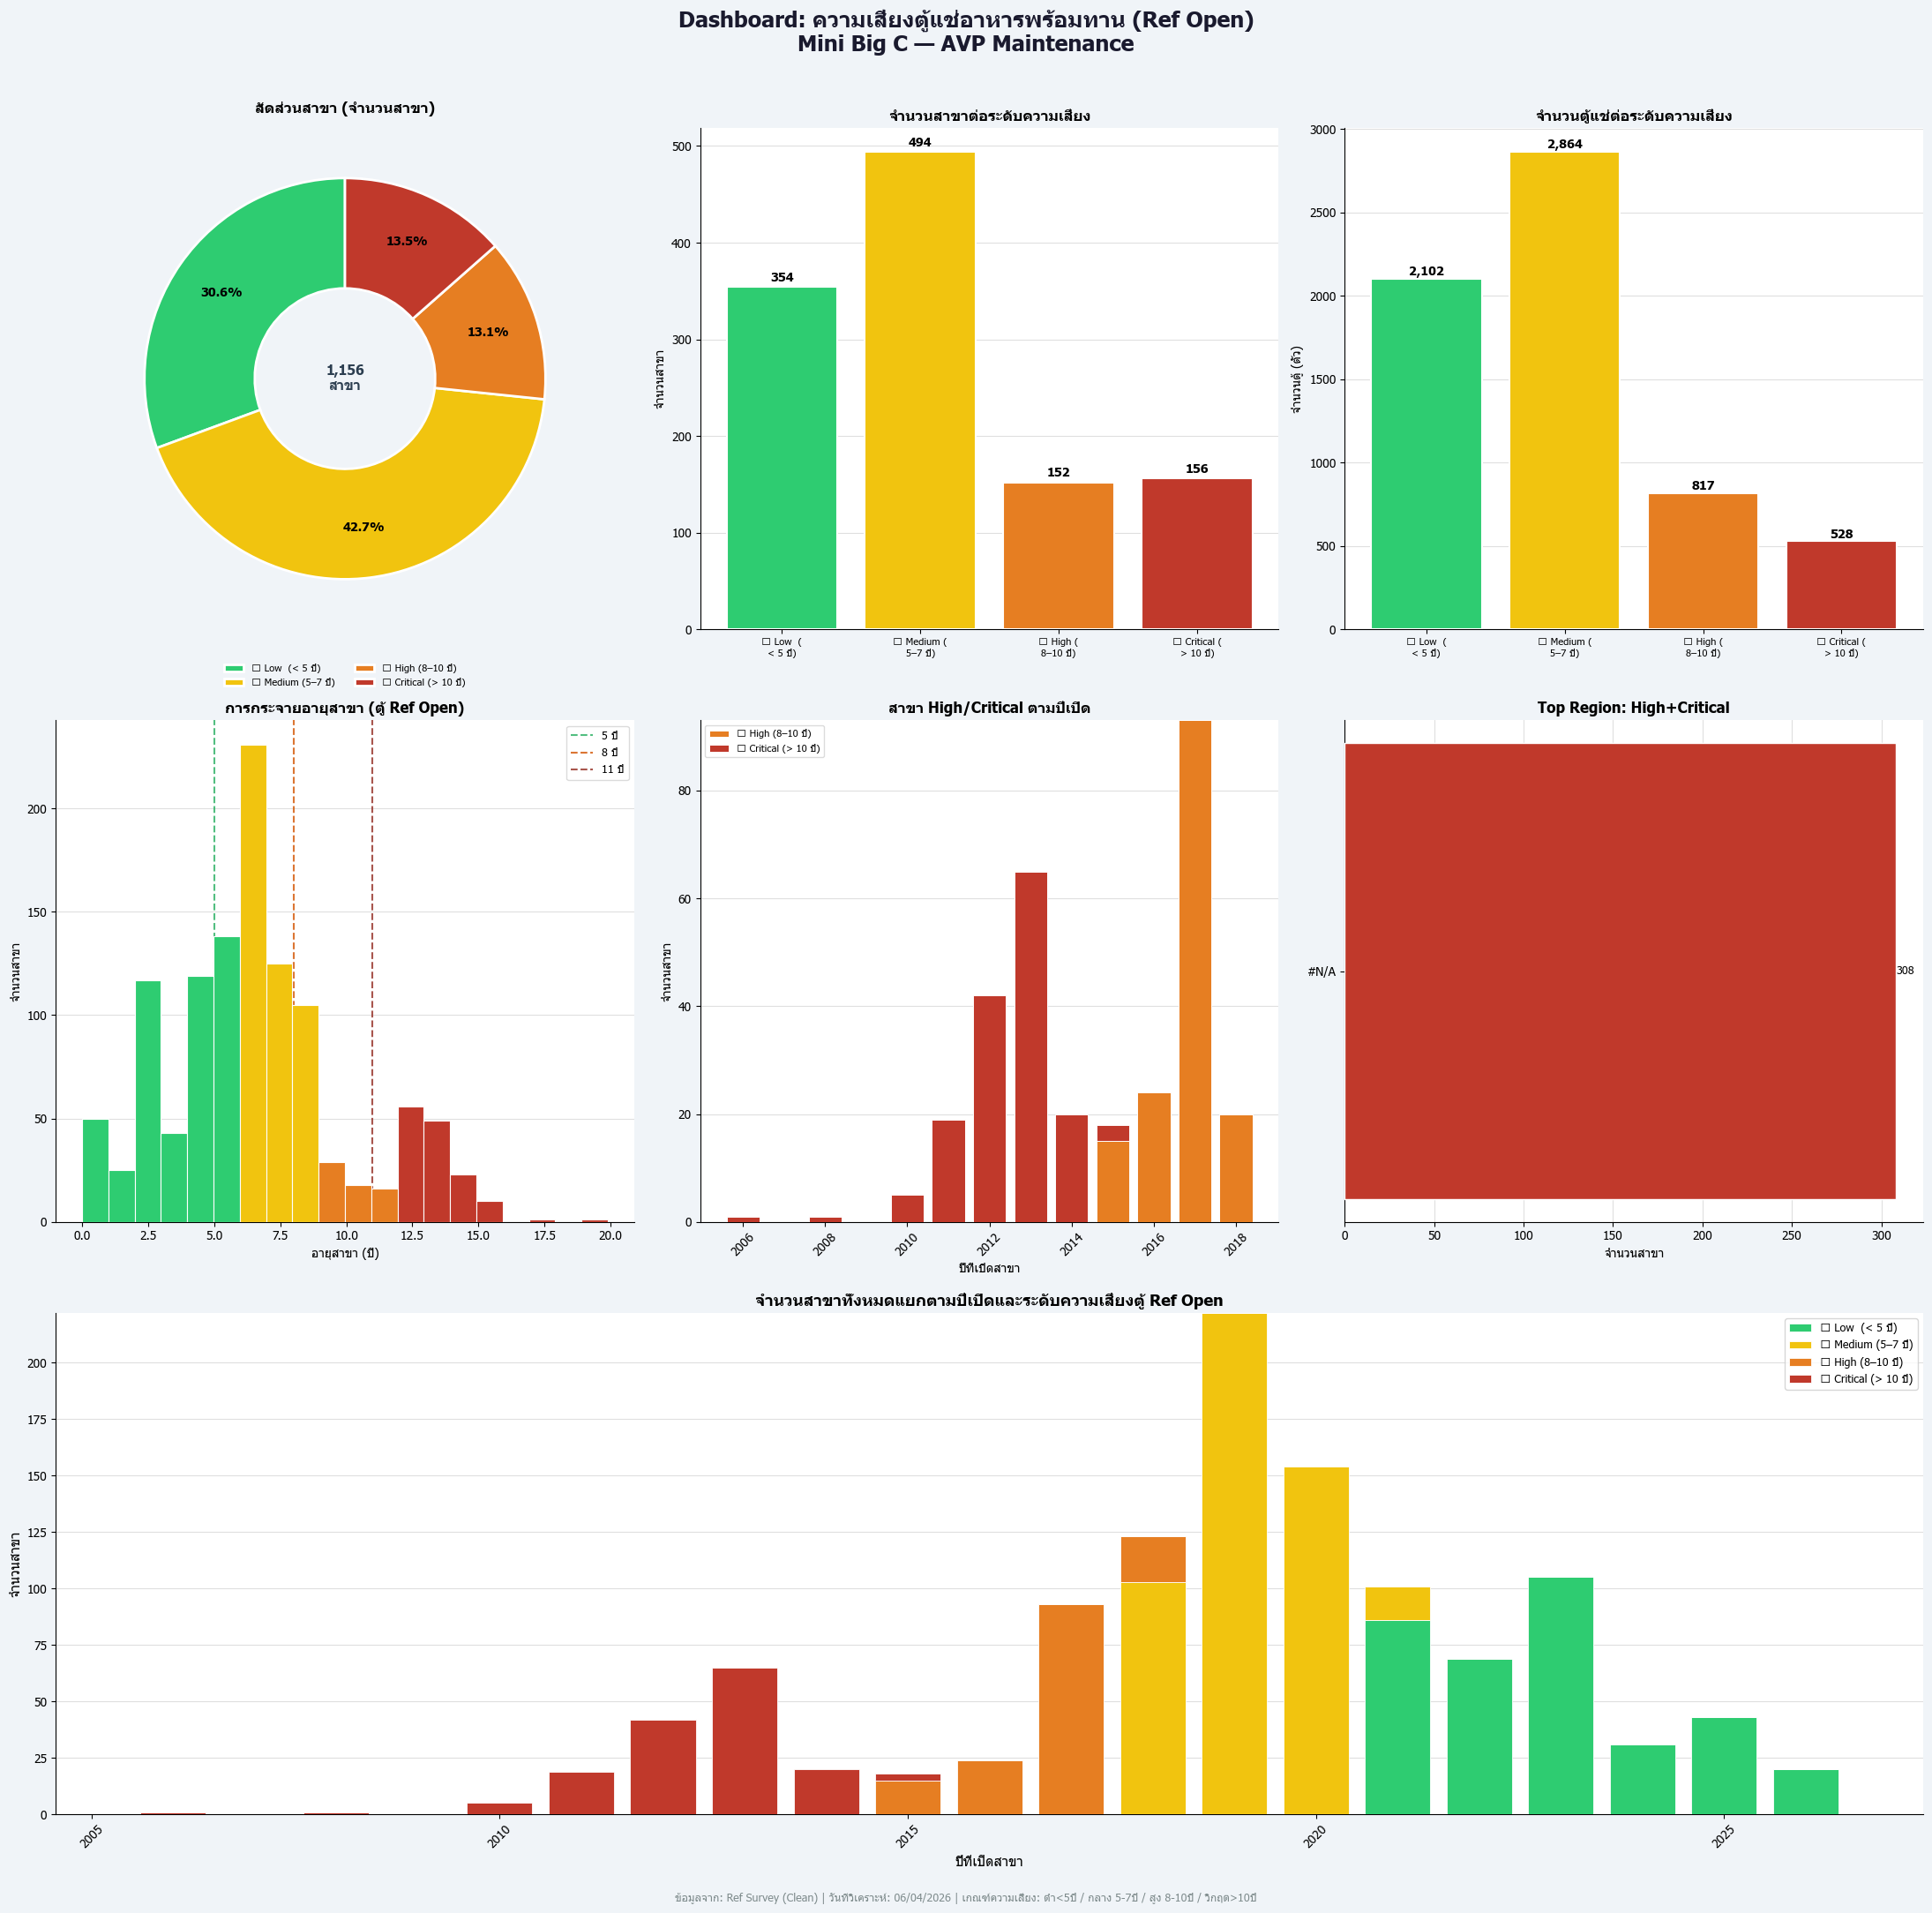

✅ Dashboard saved


In [18]:
# ═══════════════════════════════════════════════════════════
# 5.  Dashboard — 6 Charts
# ═══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 22), facecolor='#f0f4f8')
fig.suptitle('Dashboard: ความเสี่ยงตู้แช่อาหารพร้อมทาน (Ref Open)\nMini Big C — AVP Maintenance',
             fontsize=18, fontweight='bold', y=0.98, color='#1a1a2e')

PALETTE = [RISK_COLORS_HEX[k] for k in RISK_ORDER_KEYS if k in analysis_df['Risk Key'].unique()]
LABELS  = risk_summary['Label'].tolist()
RISK_KEY_LIST = [k for k in RISK_ORDER_KEYS if k in analysis_df['Risk Key'].unique()]

# ── Chart 1: Donut — สัดส่วนสาขา ──
ax1 = fig.add_subplot(3, 3, 1)
wedges, texts, autotexts = ax1.pie(
    risk_summary['Stores'], labels=None, colors=PALETTE,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
ax1.legend(wedges, LABELS, loc='upper center', bbox_to_anchor=(0.5, -0.05),
           fontsize=8, ncol=2, frameon=False)
ax1.set_title('สัดส่วนสาขา (จำนวนสาขา)', fontsize=12, fontweight='bold', pad=12)
total_stores = risk_summary['Stores'].sum()
ax1.text(0, 0, f'{total_stores:,}\nสาขา', ha='center', va='center',
         fontsize=11, fontweight='bold', color='#2c3e50')

# ── Chart 2: Bar — จำนวนสาขาต่อ Risk ──
ax2 = fig.add_subplot(3, 3, 2)
bars = ax2.bar(range(len(risk_summary)), risk_summary['Stores'], color=PALETTE,
               edgecolor='white', linewidth=1.5, zorder=3)
for bar, v in zip(bars, risk_summary['Stores']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
             f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_xticks(range(len(LABELS)))
ax2.set_xticklabels([l.replace('(','(\n') for l in LABELS], fontsize=8)
ax2.set_ylabel('จำนวนสาขา', fontsize=10); ax2.set_title('จำนวนสาขาต่อระดับความเสี่ยง', fontsize=12, fontweight='bold')
ax2.yaxis.grid(True, alpha=0.4, zorder=0); ax2.set_axisbelow(True)
ax2.spines[['top','right']].set_visible(False)

# ── Chart 3: Bar — จำนวนตู้ต่อ Risk ──
ax3 = fig.add_subplot(3, 3, 3)
bars3 = ax3.bar(range(len(risk_summary)), risk_summary['Units'], color=PALETTE,
                edgecolor='white', linewidth=1.5, zorder=3)
for bar, v in zip(bars3, risk_summary['Units']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_xticks(range(len(LABELS)))
ax3.set_xticklabels([l.replace('(','(\n') for l in LABELS], fontsize=8)
ax3.set_ylabel('จำนวนตู้ (ตัว)', fontsize=10); ax3.set_title('จำนวนตู้แช่ต่อระดับความเสี่ยง', fontsize=12, fontweight='bold')
ax3.yaxis.grid(True, alpha=0.4, zorder=0); ax3.set_axisbelow(True)
ax3.spines[['top','right']].set_visible(False)

# ── Chart 4: Histogram — การกระจายอายุ ──
ax4 = fig.add_subplot(3, 3, 4)
ages = analysis_df['Store Age (yrs)'].dropna()
n, bins, patches = ax4.hist(ages, bins=20, edgecolor='white', linewidth=0.8, color='#3498db', zorder=3)
# ระบายสีตาม risk zone
for patch, left in zip(patches, bins[:-1]):
    if left < 5:    patch.set_facecolor('#2ecc71')
    elif left < 8:  patch.set_facecolor('#f1c40f')
    elif left < 11: patch.set_facecolor('#e67e22')
    else:           patch.set_facecolor('#c0392b')
ax4.axvline(5,  color='#27ae60', linestyle='--', lw=1.5, alpha=0.8, label='5 ปี')
ax4.axvline(8,  color='#d35400', linestyle='--', lw=1.5, alpha=0.8, label='8 ปี')
ax4.axvline(11, color='#922b21', linestyle='--', lw=1.5, alpha=0.8, label='11 ปี')
ax4.set_xlabel('อายุสาขา (ปี)', fontsize=10); ax4.set_ylabel('จำนวนสาขา', fontsize=10)
ax4.set_title('การกระจายอายุสาขา (ตู้ Ref Open)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9, framealpha=0.7)
ax4.yaxis.grid(True, alpha=0.4, zorder=0); ax4.set_axisbelow(True)
ax4.spines[['top','right']].set_visible(False)

# ── Chart 5: Open Year Bar (สาขาที่เปิดแต่ละปี ของกลุ่ม High+Critical) ──
ax5 = fig.add_subplot(3, 3, 5)
hc_df = analysis_df[analysis_df['Risk Key'].isin(['3_High', '4_Critical'])].copy()
hc_df['Open Year'] = hc_df['Open Year'].fillna(0).astype(int)
yr_counts = hc_df[hc_df['Open Year'] > 2000].groupby(['Open Year','Risk Key']).size().unstack(fill_value=0)
yr_counts = yr_counts.reindex(columns=[k for k in RISK_ORDER_KEYS if k in yr_counts.columns])
bottom = np.zeros(len(yr_counts))
for key in yr_counts.columns:
    color = RISK_COLORS_HEX[key]
    ax5.bar(yr_counts.index, yr_counts[key], bottom=bottom, color=color,
            edgecolor='white', linewidth=0.7, label=RISK_LABEL[key], zorder=3)
    bottom += yr_counts[key].values
ax5.set_xlabel('ปีที่เปิดสาขา'); ax5.set_ylabel('จำนวนสาขา')
ax5.set_title('สาขา High/Critical ตามปีเปิด', fontsize=12, fontweight='bold')
ax5.legend(fontsize=8, framealpha=0.7)
ax5.tick_params(axis='x', rotation=45)
ax5.yaxis.grid(True, alpha=0.4, zorder=0); ax5.set_axisbelow(True)
ax5.spines[['top','right']].set_visible(False)

# ── Chart 6: Top 15 Region/Area — High+Critical ──
ax6 = fig.add_subplot(3, 3, 6)
region_col = 'BCM CM Region' if 'BCM CM Region' in analysis_df.columns else 'CM Area'
hc_region = (hc_df.groupby(region_col).size().sort_values(ascending=True).tail(15))
colors6 = ['#c0392b' if v >= hc_region.quantile(0.75) else '#e67e22'
           for v in hc_region.values]
ax6.barh(hc_region.index, hc_region.values, color=colors6, edgecolor='white', zorder=3)
for i, v in enumerate(hc_region.values):
    ax6.text(v+0.3, i, str(v), va='center', fontsize=9)
ax6.set_xlabel('จำนวนสาขา'); ax6.set_title('Top Region: High+Critical', fontsize=12, fontweight='bold')
ax6.xaxis.grid(True, alpha=0.4, zorder=0); ax6.set_axisbelow(True)
ax6.spines[['top','right']].set_visible(False)

# ── Chart 7–8: Box plot อายุตาม region + Scatter ──
ax7 = fig.add_subplot(3, 1, 3)
open_yr_all = analysis_df[analysis_df['Open Year'] > 2000].copy()
yr_risk = open_yr_all.groupby(['Open Year','Risk Key']).size().unstack(fill_value=0)
yr_risk = yr_risk.reindex(columns=[k for k in RISK_ORDER_KEYS if k in yr_risk.columns])
bottom7 = np.zeros(len(yr_risk))
for key in yr_risk.columns:
    color = RISK_COLORS_HEX[key]
    ax7.bar(yr_risk.index, yr_risk[key], bottom=bottom7, color=color,
            edgecolor='white', linewidth=0.6, label=RISK_LABEL[key], zorder=3, width=0.8)
    bottom7 += yr_risk[key].values
ax7.set_xlabel('ปีที่เปิดสาขา', fontsize=11); ax7.set_ylabel('จำนวนสาขา', fontsize=11)
ax7.set_title('จำนวนสาขาทั้งหมดแยกตามปีเปิดและระดับความเสี่ยงตู้ Ref Open',
              fontsize=13, fontweight='bold')
ax7.legend(fontsize=9, framealpha=0.8, loc='upper right')
ax7.tick_params(axis='x', rotation=45)
ax7.yaxis.grid(True, alpha=0.4, zorder=0); ax7.set_axisbelow(True)
ax7.spines[['top','right']].set_visible(False)

# ── footnote ──
fig.text(0.5, 0.005,
         f'ข้อมูลจาก: Ref Survey (Clean) | วันที่วิเคราะห์: {TODAY.strftime("%d/%m/%Y")} | '
         f'เกณฑ์ความเสี่ยง: ต่ำ<5ปี / กลาง 5-7ปี / สูง 8-10ปี / วิกฤต>10ปี',
         ha='center', fontsize=9, color='#7f8c8d', style='italic')

plt.tight_layout(rect=[0, 0.015, 1, 0.97])
plt.savefig(r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\RefOpen_Risk_Dashboard.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Dashboard saved")

In [19]:
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.worksheet.table import Table, TableStyleInfo
from openpyxl.drawing.image import Image as XLImage
import os

OUT_XL = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\RefOpen_Risk_Report.xlsx'

# ── Style helpers ──
def xfill(hex_str):   return PatternFill("solid", fgColor=hex_str.lstrip('#'))
def xfont(bold=False, color="000000", size=10): return Font(bold=bold, color=color, size=size)
BORDER = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'),  bottom=Side(style='thin'))

RISK_HEX = {'1_Low':'2ecc71','2_Medium':'f1c40f','3_High':'e67e22','4_Critical':'c0392b','Unknown':'95a5a6'}
RISK_FONT_COLOR = {'1_Low':'FFFFFF','2_Medium':'1a1a1a','3_High':'FFFFFF','4_Critical':'FFFFFF','Unknown':'FFFFFF'}

def write_cell(ws, row, col, val, fill=None, bold=False, font_color='000000',
               size=10, center=False, wrap=False, num_fmt=None, border=True):
    c = ws.cell(row=row, column=col, value=val)
    if fill:  c.fill = fill
    c.font  = Font(bold=bold, color=font_color, size=size)
    c.alignment = Alignment(horizontal='center' if center else 'left',
                            vertical='center', wrap_text=wrap)
    if border: c.border = BORDER
    if num_fmt: c.number_format = num_fmt
    return c

wb = Workbook()

# ═══════════════════════════════════════════════════════════
# SHEET 1 : Dashboard Image
# ═══════════════════════════════════════════════════════════
ws_dash = wb.active
ws_dash.title = "Dashboard"
ws_dash.sheet_view.showGridLines = False
IMG_PATH = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\RefOpen_Risk_Dashboard.png'
if os.path.exists(IMG_PATH):
    img = XLImage(IMG_PATH)
    img.anchor = 'A1'
    ws_dash.add_image(img)
    ws_dash.column_dimensions['A'].width = 160
    ws_dash.row_dimensions[1].height = 900

# ═══════════════════════════════════════════════════════════
# SHEET 2 : Summary
# ═══════════════════════════════════════════════════════════
ws_s = wb.create_sheet("Risk Summary")
ws_s.sheet_view.showGridLines = False

# Title
ws_s.merge_cells("A1:H1")
write_cell(ws_s, 1, 1,
    f'สรุปความเสี่ยงตู้แช่อาหารพร้อมทาน (Ref Open) — Mini Big C  |  วันที่: {TODAY.strftime("%d/%m/%Y")}',
    fill=xfill('1F4E79'), bold=True, font_color='FFFFFF', size=14, center=True)
ws_s.row_dimensions[1].height = 32

# Sub-title
for c, txt in enumerate(['ระดับความเสี่ยง','คำอธิบาย','จำนวนสาขา','สัดส่วน (%)','จำนวนตู้ (ตัว)','สัดส่วนตู้ (%)','อายุเฉลี่ย (ปี)','Action แนะนำ'], 1):
    write_cell(ws_s, 2, c, txt, fill=xfill('2E75B6'), bold=True, font_color='FFFFFF', size=10, center=True)
ws_s.row_dimensions[2].height = 20

total_stores2 = risk_summary['Stores'].sum()
total_units2  = risk_summary['Units'].sum()

actions = {
    '1_Low':      'Monitor ปกติ — Survey ปีละ 1 ครั้ง',
    '2_Medium':   'Preventive Maintenance ก่อนครบ 8 ปี',
    '3_High':     'PM เร่งด่วน + วางแผน Replace ภายใน 1-2 ปี',
    '4_Critical': 'Replace ทันที — ความเสี่ยงสูง (เกิน 10 ปี)',
    'Unknown':    'ตรวจสอบ Date Open Store'
}
desc = {
    '1_Low':      'อายุ < 5 ปี — ยังอยู่ในช่วงใช้งานปกติ',
    '2_Medium':   'อายุ 5–7 ปี — เริ่มเข้าสู่ช่วงเฝ้าระวัง',
    '3_High':     'อายุ 8–10 ปี — ใกล้ถึงอายุการใช้งานมาตรฐาน',
    '4_Critical': 'อายุ > 10 ปี — เกินอายุการใช้งานมาตรฐาน',
    'Unknown':    'ไม่มีข้อมูลวันเปิดสาขา'
}

row3 = 3
for _, r in risk_summary.iterrows():
    k = r['Risk Key']
    pct_s = r['Stores'] / total_stores2 * 100
    pct_u = r['Units']  / total_units2  * 100
    fg = xfill(RISK_HEX[k])
    fc = RISK_FONT_COLOR[k]
    write_cell(ws_s, row3, 1, r['Label'],    fill=fg, bold=True, font_color=fc, center=True)
    write_cell(ws_s, row3, 2, desc[k],       fill=fg, font_color=fc, wrap=True)
    write_cell(ws_s, row3, 3, r['Stores'],   fill=fg, bold=True, font_color=fc, center=True, num_fmt='#,##0')
    write_cell(ws_s, row3, 4, round(pct_s,1),fill=fg, font_color=fc, center=True, num_fmt='0.0"%"')
    write_cell(ws_s, row3, 5, r['Units'],    fill=fg, bold=True, font_color=fc, center=True, num_fmt='#,##0')
    write_cell(ws_s, row3, 6, round(pct_u,1),fill=fg, font_color=fc, center=True, num_fmt='0.0"%"')
    write_cell(ws_s, row3, 7, r['AvgAge'],   fill=fg, font_color=fc, center=True, num_fmt='0.0')
    write_cell(ws_s, row3, 8, actions[k],    fill=fg, font_color=fc, wrap=True)
    ws_s.row_dimensions[row3].height = 28
    row3 += 1

# Total row
write_cell(ws_s, row3, 1, 'รวมทั้งหมด', fill=xfill('BDD7EE'), bold=True, center=True)
write_cell(ws_s, row3, 2, '', fill=xfill('BDD7EE'))
write_cell(ws_s, row3, 3, total_stores2, fill=xfill('BDD7EE'), bold=True, center=True, num_fmt='#,##0')
write_cell(ws_s, row3, 4, 100.0, fill=xfill('BDD7EE'), center=True, num_fmt='0.0"%"')
write_cell(ws_s, row3, 5, total_units2, fill=xfill('BDD7EE'), bold=True, center=True, num_fmt='#,##0')
write_cell(ws_s, row3, 6, 100.0, fill=xfill('BDD7EE'), center=True, num_fmt='0.0"%"')
write_cell(ws_s, row3, 7, '', fill=xfill('BDD7EE'))
write_cell(ws_s, row3, 8, '', fill=xfill('BDD7EE'))
ws_s.row_dimensions[row3].height = 22

# column widths
for ci, w in zip(range(1,9), [28, 40, 14, 12, 14, 12, 14, 45]):
    ws_s.column_dimensions[get_column_letter(ci)].width = w

# ═══════════════════════════════════════════════════════════
# SHEET 3 : High & Critical Store List (Action List)
# ═══════════════════════════════════════════════════════════
ws_hc = wb.create_sheet("Action List (High+Critical)")
hc_export = analysis_df[analysis_df['Risk Key'].isin(['3_High','4_Critical'])].copy()
hc_export = hc_export.sort_values(['Risk Key','Store Age (yrs)'], ascending=[True, False])

hc_cols = ['Branch Code','Branch Name','Store Name(th) (2)','CM Area','DM Area',
           'Province','HUB (18)','Date Open Store','Store Age (yrs)',
           'Ref Open Qty Num','Risk Level']
hc_out = hc_export[[c for c in hc_cols if c in hc_export.columns]].copy()
hc_out['Date Open Store'] = hc_out['Date Open Store'].dt.strftime('%d/%m/%Y') if hasattr(hc_out['Date Open Store'].dtype, 'tz') else hc_out['Date Open Store'].astype(str)

col_headers = {
    'Branch Code':'รหัสสาขา','Branch Name':'ชื่อสาขา','Store Name(th) (2)':'ชื่อสาขา (Master)',
    'CM Area':'CM Area','DM Area':'DM Area','Province':'จังหวัด','HUB (18)':'HUB',
    'Date Open Store':'วันเปิดสาขา','Store Age (yrs)':'อายุ (ปี)',
    'Ref Open Qty Num':'จำนวนตู้ Ref Open','Risk Level':'ระดับความเสี่ยง'
}
display_cols = [c for c in hc_cols if c in hc_out.columns]
header_labels = [col_headers.get(c, c) for c in display_cols]

# Header row
for ci, h_label in enumerate(header_labels, 1):
    write_cell(ws_hc, 1, ci, h_label, fill=xfill('1F4E79'), bold=True,
               font_color='FFFFFF', size=10, center=True)
ws_hc.row_dimensions[1].height = 22

# Data rows
for ri, (_, row_data) in enumerate(hc_out.iterrows(), 2):
    k = row_data.get('Risk Key', '') if 'Risk Key' in row_data else ''
    risk_str = str(row_data.get('Risk Level', ''))
    if '4_Critical' in str(hc_export.loc[row_data.name, 'Risk Key'] if row_data.name in hc_export.index else '') or 'Critical' in risk_str:
        row_fill = xfill('FADBD8')
    else:
        row_fill = xfill('FDEBD0') if ri % 2 == 0 else xfill('FEF9E7')
    for ci, col_name in enumerate(display_cols, 1):
        val = row_data.get(col_name, '')
        nf = '#,##0.0' if col_name == 'Store Age (yrs)' else ('#,##0' if col_name == 'Ref Open Qty Num' else None)
        write_cell(ws_hc, ri, ci, val, fill=row_fill, num_fmt=nf,
                   center=(col_name in ['Branch Code','Store Age (yrs)','Ref Open Qty Num','Date Open Store']))

# Excel Table
tbl_ref = f"A1:{get_column_letter(len(display_cols))}{len(hc_out)+1}"
tbl_hc = Table(displayName="ActionList", ref=tbl_ref)
tbl_hc.tableStyleInfo = TableStyleInfo(name="TableStyleMedium3",
    showRowStripes=True, showFirstColumn=False, showLastColumn=False)
ws_hc.add_table(tbl_hc)
ws_hc.freeze_panes = "A2"

# auto width
for ci, col_name in enumerate(display_cols, 1):
    vals = [str(col_headers.get(col_name, col_name))] + [str(v) for v in hc_out[col_name].head(100)]
    w = min(max(len(v) for v in vals) + 2, 40)
    ws_hc.column_dimensions[get_column_letter(ci)].width = w

print(f"Action List: {len(hc_out)} สาขา (High: {(hc_export['Risk Key']=='3_High').sum()}, Critical: {(hc_export['Risk Key']=='4_Critical').sum()})")

# ═══════════════════════════════════════════════════════════
# SHEET 4 : Full Data — All stores with risk
# ═══════════════════════════════════════════════════════════
ws_all = wb.create_sheet("All Stores - Ref Open")
all_export = analysis_df.sort_values(['Risk Key','Store Age (yrs)'], ascending=[True, False]).copy()
all_export = all_export[[c for c in hc_cols if c in all_export.columns]]

all_display = [c for c in hc_cols if c in all_export.columns]
all_labels  = [col_headers.get(c, c) for c in all_display]

for ci, h_label in enumerate(all_labels, 1):
    write_cell(ws_all, 1, ci, h_label, fill=xfill('1F4E79'), bold=True,
               font_color='FFFFFF', size=10, center=True)
ws_all.row_dimensions[1].height = 22

for ri, (_, row_data) in enumerate(all_export.iterrows(), 2):
    rl = str(row_data.get('Risk Level', ''))
    if 'Critical' in rl:   rf = xfill('FADBD8')
    elif 'High' in rl:     rf = xfill('FDEBD0')
    elif 'Medium' in rl:   rf = xfill('FEFDE7') if ri%2==0 else None
    else:                   rf = xfill('EAFAF1') if ri%2==0 else None
    for ci, col_name in enumerate(all_display, 1):
        val = row_data.get(col_name, '')
        nf = '#,##0.0' if col_name == 'Store Age (yrs)' else ('#,##0' if col_name == 'Ref Open Qty Num' else None)
        write_cell(ws_all, ri, ci, val, fill=rf, num_fmt=nf,
                   center=(col_name in ['Branch Code','Store Age (yrs)','Ref Open Qty Num','Date Open Store']))

tbl_all_ref = f"A1:{get_column_letter(len(all_display))}{len(all_export)+1}"
tbl_all = Table(displayName="AllStoresRefOpen", ref=tbl_all_ref)
tbl_all.tableStyleInfo = TableStyleInfo(name="TableStyleMedium2", showRowStripes=True)
ws_all.add_table(tbl_all)
ws_all.freeze_panes = "A2"
for ci, col_name in enumerate(all_display, 1):
    vals = [str(all_labels[ci-1])] + [str(v) for v in all_export[col_name].head(100)]
    ws_all.column_dimensions[get_column_letter(ci)].width = min(max(len(v) for v in vals)+2, 40)

# ── Save ──
wb.save(OUT_XL)
print(f"\n✅ Saved: {OUT_XL}")
print(f"   Sheet 'Dashboard'           : รูป Dashboard")
print(f"   Sheet 'Risk Summary'        : สรุปความเสี่ยง 4 ระดับ")
print(f"   Sheet 'Action List'         : {len(hc_out)} สาขา High+Critical")
print(f"   Sheet 'All Stores - Ref Open': {len(all_export)} สาขา ทุก Risk Level")

Action List: 308 สาขา (High: 152, Critical: 156)

✅ Saved: G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\RefOpen_Risk_Report.xlsx
   Sheet 'Dashboard'           : รูป Dashboard
   Sheet 'Risk Summary'        : สรุปความเสี่ยง 4 ระดับ
   Sheet 'Action List'         : 308 สาขา High+Critical
   Sheet 'All Stores - Ref Open': 1156 สาขา ทุก Risk Level
